# Sentiment Analysis in Python
This notebook performs sentiment analysis on a dataset using different machine learning models.

## Step 1: Setup and Data Loading
We first load the dataset and inspect its structure.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import re

In [ ]:
# Load the dataset
df = pd.read_csv('./wiki/wiki.csv')

## Step 2: Data Understanding
We check the first few rows, dataset dimensions, and descriptions.

In [ ]:

# Display first two rows
print("First two rows:")
df.head(2)


First two rows:
                 title                                            content  \
0  AccessibleComputing  #REDIRECT [[Computer accessibility]]\n\n{{rcat...   
1            Anarchism  {{short description|Political philosophy and m...   

   categories  
0  not_births  
1  not_births  


In [5]:
# Dataset dimensions
df.shape

(27376, 3)

In [6]:
# Dataset description
df.describe(include='all')

,title,content,categories
count,27376,27376,27376
unique,27376,26647,2
top,AccessibleComputing,This (now-obsolete) page contains (in its hist...,not_births
freq,1,35,24398


## Step 3: Data Preprocessing
We clean the text data by removing punctuation, stopwords, and applying stemming.

In [7]:

# Data Preprocessing
nltk.download('stopwords')
nltk.download('punkt')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['cleaned_content'] = df['content'].apply(clean_text)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\marcl\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\marcl\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Step 4: Exploratory Data Analysis (EDA)
We visualize the distribution of categories and common words.

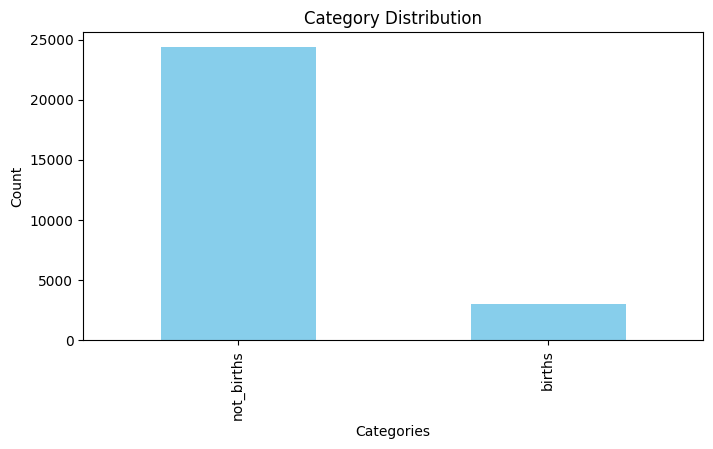

In [8]:

plt.figure(figsize=(8, 4))
df['categories'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Category Distribution')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.show()

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df['cleaned_content']))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Text Data')
plt.show()

## Step 5: Feature Engineering
We transform text data into numerical features using TF-IDF.

In [ ]:

# Feature Engineering
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_content'])
y = df['categories']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Step 6: Model Training and Evaluation
We train three different models and compare their performance.

In [ ]:

# Model Training and Comparison
models = {
    'Logistic Regression': LogisticRegression(),
    'Naïve Bayes': MultinomialNB(),
    'Support Vector Machine': SVC()
}

results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[model_name] = acc
    print(f"\n{model_name} Performance:")
    print(classification_report(y_test, y_pred))


## Step 7: Results and Visualization
We visualize model accuracy and confusion matrices.

In [ ]:

# Model Evaluation
plt.figure(figsize=(8, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='coolwarm')
plt.title('Model Comparison: Accuracy Scores')
plt.ylabel('Accuracy')
plt.xlabel('Models')
plt.ylim(0, 1)
plt.show()

# Confusion Matrix for the best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred_best)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f'Best Model: {best_model_name} with Accuracy {results[best_model_name]:.2f}')
